# Figure 5: Multiple occluders, trajectory analysis

In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
cd "/app/"

/app


/app/.venv/lib/python3.9/site-packages/IPython/core/magics/osm.py:417: UserWarning: using dhist requires you to install the `pickleshare` library.
  self.shell.db['dhist'] = compress_dhist(dhist)[-100:]


In [3]:
%run env_aws.py
%run run.py connect

/app/.venv/lib/python3.9/site-packages/datajoint/plugin.py:2: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  import pkg_resources
[2026-02-17 13:41:05,530][INFO]: Connecting admin@vr4mice-ar-collab.cluster-cn54f38qpzgm.eu-central-1.rds.amazonaws.com:3306
[2026-02-17 13:41:05,679][INFO]: Connected admin@vr4mice-ar-collab.cluster-cn54f38qpzgm.eu-central-1.rds.amazonaws.com:3306


In [4]:
from vr4mice.schema.base_analysis import DataFrame
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from vr4mice.analysis import plotting
from base_schemas.schemas.exp import Session
from vr4mice.schema import base_analysis
from vr4mice.analysis.analysis import style
from vr4mice.analysis import analysis
from vr4mice.schema import dlc, vr4mice
from vr4mice.analysis import utils
from vr4mice.schema.vr4mice import Groups, Labels
from vr4mice.schema.session_metrics import TrialMetrics
from vr4mice.schema.interpolated_trajectories import InterpolatedTrials, MeanXYTrajectory, YBinnedXYTrajectory, MeanVelocities
from vr4mice.analysis.analysis import mean_xy_trajectory
from vr4mice.analysis.stats import get_p_values_multi, get_multi_performance_p_val, plot_aperture_heatmap

from statsmodels.stats.anova import AnovaRM
from scipy.stats import ttest_rel, ttest_ind
import statsmodels.formula.api as smf
import scipy.stats as stats

style()

save_fig_path = "notebooks/Paper_figures/Figure_output/"

/app/.venv/lib/python3.9/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [5]:
trial_df = (Groups() * (Labels()  & 'label = "ar_paper"') * (vr4mice.Dataset() & 'session_label = "ar_discrim_5_occluders"') * TrialMetrics()).fetch(as_dict=True)
trial_df = pd.concat([pd.DataFrame(x) for x in trial_df])
trial_df ["aperture"] = trial_df.aperture.round(2)
trial_df, reward_table = utils.apply_inclusion_criteria(trial_df[["dataset", "aperture", "trial", "trial_left_choice", "trial_rewarded", "trial_tortuosity", "trial_duration"]],
                                                        return_excluded=False)

# Create list of included datasets
mouse_list = trial_df.dataset.unique()
trial_df["mouse_name"] = trial_df.dataset.str.split("_").str [0]

In [6]:
trial_df.mouse_name.nunique(), trial_df.dataset.nunique()

(9, 25)

In [7]:
trial_df.groupby("mouse_name").nunique().dataset

mouse_name
31726          2
31728          2
J729           4
Jacana         2
Kiwi           3
Lemming        3
Nightingale    4
Oribi          3
Pheasant       2
Name: dataset, dtype: int64

In [8]:
trial_df.dataset.unique()

array(['31726_2025-03-27_1', '31726_2025-03-28_1', '31728_2025-03-11_1',
       '31728_2025-03-14_1', 'J729_2024-12-11_1', 'J729_2024-12-12_1',
       'J729_2024-12-13_1', 'J729_2024-12-15_1', 'Jacana_2024-08-21_1',
       'Jacana_2024-08-22_1', 'Kiwi_2024-08-19_1', 'Kiwi_2024-08-20_1',
       'Kiwi_2024-08-21_1', 'Lemming_2024-08-14_1',
       'Lemming_2024-08-15_1', 'Lemming_2024-08-19_1',
       'Nightingale_2024-08-15_1', 'Nightingale_2024-08-16_1',
       'Nightingale_2024-08-21_1', 'Nightingale_2024-08-22_1',
       'Oribi_2024-08-26_1', 'Oribi_2024-08-27_1', 'Oribi_2024-08-29_1',
       'Pheasant_2024-08-26_1', 'Pheasant_2024-08-28_1'], dtype=object)

In [9]:
trial_df["lab_id"] = 0
for dataset_name in mouse_list:
    # Fetch lab_id for each dataset
    trial_df.loc[trial_df.dataset==dataset_name, "lab_id"] = ((vr4mice.Collab() & f'dataset = "{dataset_name}"') * vr4mice.Labs()).fetch("lab")[0]

In [10]:
# Linear Mixed Model (with Mouse)
lmm_model = smf.mixedlm("trial_rewarded ~ C(aperture)", 
                        data=trial_df, groups=trial_df["mouse_name"]).fit(method='bfgs')

# Ordinary Least Squares (without Mouse)
ols_model = smf.ols("trial_rewarded ~ C(aperture)", data=trial_df).fit()

# Likelihood Ratio Test
lr_stat = 2 * (lmm_model.llf - ols_model.llf)
p_val = stats.chi2.sf(lr_stat, df=1) # 1 degree of freedom for the random effect

print(f"LRT Statistic: {lr_stat:.4f}")
print(f"P-value for Mouse effect: {p_val:.4f}")

if p_val > 0.05:
    print("Justification: Mouse identity does not significantly improve the model. Independent ANOVA is valid.")
else:
    print("Caution: Mouse identity explains significant variance.")

LRT Statistic: 258.5593
P-value for Mouse effect: 0.0000
Caution: Mouse identity explains significant variance.


                Anova
         F Value Num DF  Den DF Pr > F
--------------------------------------
aperture  0.0901 4.0000 96.0000 0.9854



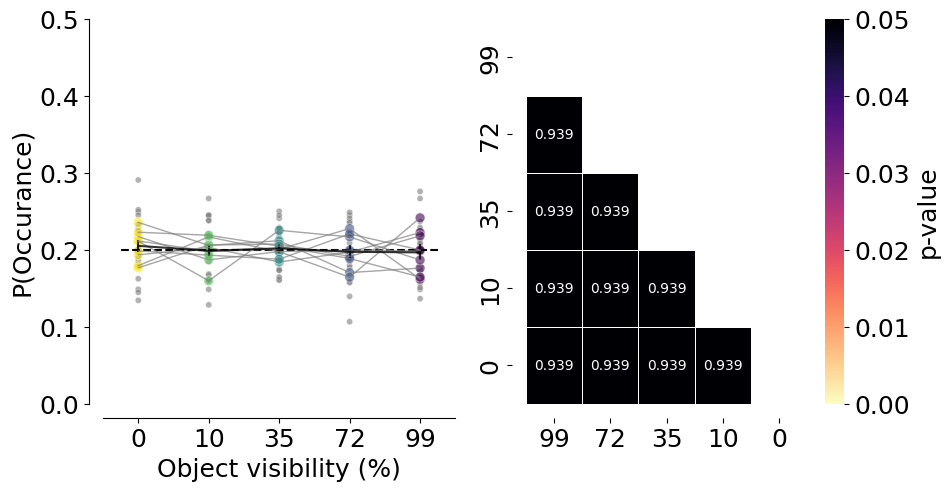

In [11]:
# Occurance of the different conditions
counts = (
    trial_df.groupby(["dataset", "mouse_name", "aperture"])
    .trial.nunique()
    .reset_index(name="trial_count")
)
total_trials = (
    trial_df.groupby("dataset").trial.nunique().reset_index(name="total_trials")
)

counts = counts.merge(total_trials, on="dataset")
counts["probability"] = counts["trial_count"] / counts["total_trials"]
counts["aperture"] = counts["aperture"].astype("float")
counts = counts.sort_values("aperture")

counts["aperture_numeric"] = counts["aperture"]
aperture_order = counts["aperture"].unique()
counts["aperture"] = pd.Categorical(counts["aperture"].astype("str"), categories=aperture_order.astype("str"), ordered=True)

fig, ax = plt.subplots(1, 2, figsize=(10, 5))

sns.lineplot(
    data=counts.groupby(["aperture", "mouse_name"], as_index=False).probability.mean(),
    x="aperture",
    y="probability",
    units="mouse_name",
    estimator=None,
    color="grey",
    alpha=0.7,
    linewidth=1,
    zorder=3,
    ax=ax[0]
)

sns.scatterplot(
    data=counts.groupby(["aperture", "mouse_name"], as_index=False).probability.mean(),
    x="aperture",
    y="probability",
    hue="aperture",
    palette=plotting.colors_multi_aperture[::-1],
    alpha=0.6,
    s=50,
    zorder=2,
    ax=ax[0]
)

sns.scatterplot(
    data=counts,
    x="aperture",
    y="probability",
    hue="aperture",
    palette=["grey"] * counts["dataset"].nunique(),
    alpha=0.6,
    zorder=1,
    s=20,
    ax=ax[0]
)

sns.lineplot(
    data=counts.groupby(["aperture", "mouse_name"], as_index=False).probability.mean(),
    x="aperture",
    y="probability",
    color="black",
    err_style="bars",
    errorbar="se",
    alpha=0.8,
    zorder=4,
    ax=ax[0]
)

ax[0].hlines(
    0.2,
    xmin=-0.25,
    xmax=len(trial_df.aperture.unique()) - 0.75,
    linestyles="dashed",
    colors="k",
)

ax[0].set_ylim(0, .5)
ax[0].set_xlim(-0.5, 4.5)
ax[0].invert_xaxis()

ax[0].set_xticks([4, 3, 2, 1, 0], ["0", "10", "35", "72", "99"])

ax[0].set_xlabel("Object visibility (%)")
ax[0].set_ylabel("P(Occurance)")
sns.despine(offset=10)
ax[0].legend([], [], frameon=False)

# Use numeric aperture for statistical analysis
counts_for_stats = counts.copy()
counts_for_stats['aperture'] = counts_for_stats['aperture_numeric']
p_values = get_multi_performance_p_val(counts_for_stats,  y_var="probability")
plot_aperture_heatmap(p_values, ax= ax[1])
ax[1].set_xticks([4.5, 3.5, 2.5, 1.5, 0.5], ["0", "10", "35", "72", "99"])
ax[1].set_yticks([4.5, 3.5, 2.5, 1.5, 0.5], ["0", "10", "35", "72", "99"])

print(AnovaRM(counts_for_stats, depvar="probability", subject="dataset", within=["aperture"]).fit())

plt.savefig(save_fig_path + "figure5_occurance.svg", transparent=True)

3.0-4.2: TtestResult(statistic=-2.493988124742931, pvalue=0.019918841916005924, df=24)
3.0-6.0: TtestResult(statistic=-4.3481596890469, pvalue=0.00021792423175303471, df=24)
3.0-8.48: TtestResult(statistic=-5.936285133499774, pvalue=3.986044948258331e-06, df=24)
mean: 0.7491035247921917, sem: 0.02126242422707163
4.2-6.0: TtestResult(statistic=-2.1904409874229156, pvalue=0.03844327894682323, df=24)
4.2-8.48: TtestResult(statistic=-2.8444593290376323, pvalue=0.008952505101484732, df=24)
mean: 0.8185206190965897, sem: 0.024443425567234358
6.0-8.48: TtestResult(statistic=-0.4633245496675397, pvalue=0.6473060246641702, df=24)
mean: 0.8907193938311871, sem: 0.02122262675892403
mean: 0.9048117652784508, sem: 0.016996887099930302
12.0-3.0: TtestResult(statistic=4.847181901915849, pvalue=6.12561974792148e-05, df=24)
12.0-4.2: TtestResult(statistic=2.6168388007399845, pvalue=0.015117166807783985, df=24)
12.0-6.0: TtestResult(statistic=0.04065996451030943, pvalue=0.9679033410169438, df=24)
12.0-8

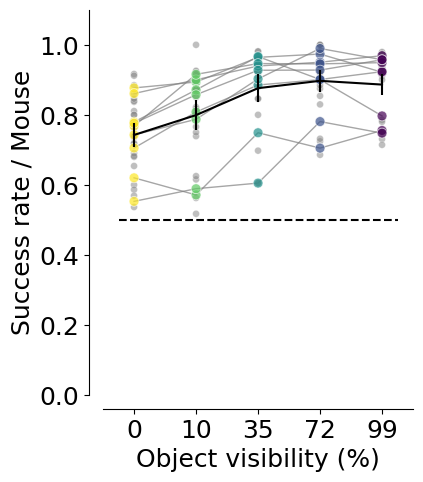

In [12]:
# Success rate per mouse
fig, ax = plt.subplots(1, 1, figsize=(4, 5))
plotting.plot_rate(
    df=trial_df,
    label_x="trial_rewarded",
    per_aperture=True,
    ax=ax,
    cmap=plotting.colors_multi_aperture,
    per_mouse=True,
)
ax.hlines(
    0.5,
    xmin=-0.25,
    xmax=len(trial_df.aperture.unique()) - 0.75,
    linestyles="dashed",
    colors="k",
)

ax.set_ylim(0, 1.1)
ax.set_xlim(-0.5, 4.5)
ax.set_xlabel("Object visibility (%)")
ax.set_ylabel("Success rate / Mouse")
ax.set_xticks([0, 1, 2, 3, 4], ["0", "10", "35", "72", "99"])

ax.legend([], [], frameon=False)
sns.despine(offset=10)

print(AnovaRM(counts_for_stats, depvar="probability", subject="dataset", within=["aperture"]).fit())

plt.savefig(save_fig_path + "figure5_rewards_per_mouse.svg", transparent=True)

3.0-4.2: TtestResult(statistic=-4.294775142156709, pvalue=0.000249592248485294, df=24)
3.0-6.0: TtestResult(statistic=-8.63596674410741, pvalue=7.938488027221137e-09, df=24)
3.0-8.48: TtestResult(statistic=-9.922891044401927, pvalue=5.716543717984163e-10, df=24)
mean: 0.7491035247921917, sem: 0.02126242422707163
4.2-6.0: TtestResult(statistic=-4.96095944839423, pvalue=4.5893003535062247e-05, df=24)
4.2-8.48: TtestResult(statistic=-5.653014738081343, pvalue=8.04406204065893e-06, df=24)
mean: 0.8185206190965897, sem: 0.02444342556723436
6.0-8.48: TtestResult(statistic=-0.9143341342926102, pvalue=0.36963645105671183, df=24)
mean: 0.8907193938311871, sem: 0.021222626758924026
mean: 0.9048117652784506, sem: 0.016996887099930302
12.0-3.0: TtestResult(statistic=9.908373156320879, pvalue=5.88184256287188e-10, df=24)
12.0-4.2: TtestResult(statistic=4.653696076204195, pvalue=0.00010017441571757577, df=24)
12.0-6.0: TtestResult(statistic=0.07659887976618203, pvalue=0.9395776368965353, df=24)
12.0

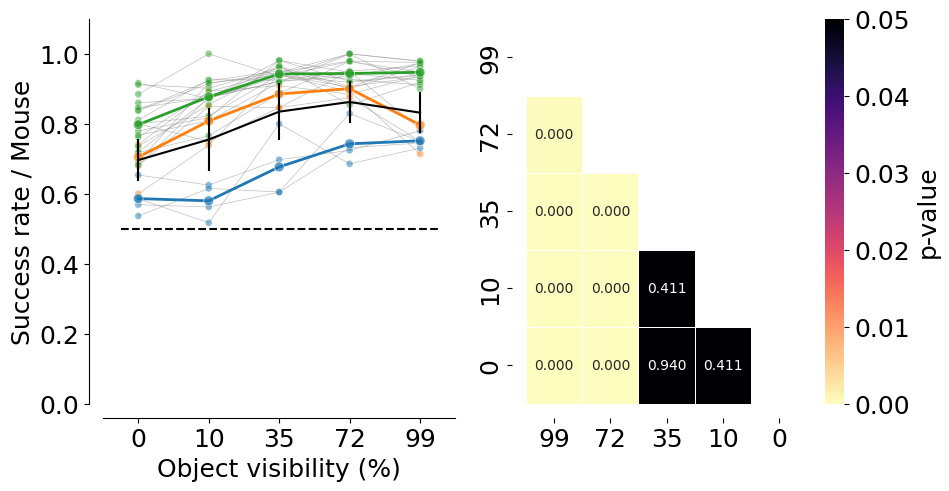

In [13]:
# Success rate per mouse
fig, ax = plt.subplots(1, 2, figsize=(10, 5))
plotting.plot_rate(
    df=trial_df,
    label_x="trial_rewarded",
    per_aperture=True,
    ax=ax[0],
    cmap=plotting.colors_multi_aperture,
    per_lab=True,
)
ax[0].hlines(
    0.5,
    xmin=-0.25,
    xmax=len(trial_df.aperture.unique()) - 0.75,
    linestyles="dashed",
    colors="k",
)

ax[0].set_ylim(0, 1.1)
ax[0].set_xlim(-0.5, 4.5)
ax[0].set_xlabel("Object visibility (%)")
ax[0].set_ylabel("Success rate / Mouse")
ax[0].set_xticks([0, 1, 2, 3, 4], ["0", "10", "35", "72", "99"])

ax[0].legend([], [], frameon=False)
sns.despine(offset=10)

p_values = get_multi_performance_p_val(trial_df, y_var="trial_rewarded")
plot_aperture_heatmap(p_values, ax=ax[1])
ax[1].set_xticks([4.5, 3.5, 2.5, 1.5, 0.5], ["0", "10", "35", "72", "99"])
ax[1].set_yticks([4.5, 3.5, 2.5, 1.5, 0.5], ["0", "10", "35", "72", "99"])

mean_mouse = trial_df.groupby(["dataset", "aperture"], as_index=False).mean(numeric_only=True)
print(AnovaRM(mean_mouse, depvar="trial_rewarded", subject="dataset", within=["aperture"]).fit())

plt.savefig(save_fig_path + "figure5_rewards.svg", transparent=True)

3.0-4.2: TtestResult(statistic=0.16336372813892353, pvalue=0.8715999221309235, df=24)
3.0-6.0: TtestResult(statistic=0.4605874808001341, pvalue=0.6492408672893397, df=24)
3.0-8.48: TtestResult(statistic=-0.21695206601737546, pvalue=0.8300793967741364, df=24)
mean: -0.014895388375778968, sem: 0.057655475920694796
4.2-6.0: TtestResult(statistic=0.24990922807693325, pvalue=0.8047842776180888, df=24)
4.2-8.48: TtestResult(statistic=-0.4639523528123425, pvalue=0.6468625851577114, df=24)
mean: -0.029098246430540174, sem: 0.05030026955084806
6.0-8.48: TtestResult(statistic=-0.8071400388375911, pvalue=0.4275128960568405, df=24)
mean: -0.043690125044112946, sem: 0.02917310967365532
mean: -0.0016919343711977275, sem: 0.03665222503761904
12.0-3.0: TtestResult(statistic=1.039734229048693, pvalue=0.30882528560258005, df=24)
12.0-4.2: TtestResult(statistic=1.4772944346317236, pvalue=0.15260002867784161, df=24)
12.0-6.0: TtestResult(statistic=2.278039263657111, pvalue=0.031918811598357646, df=24)
12.

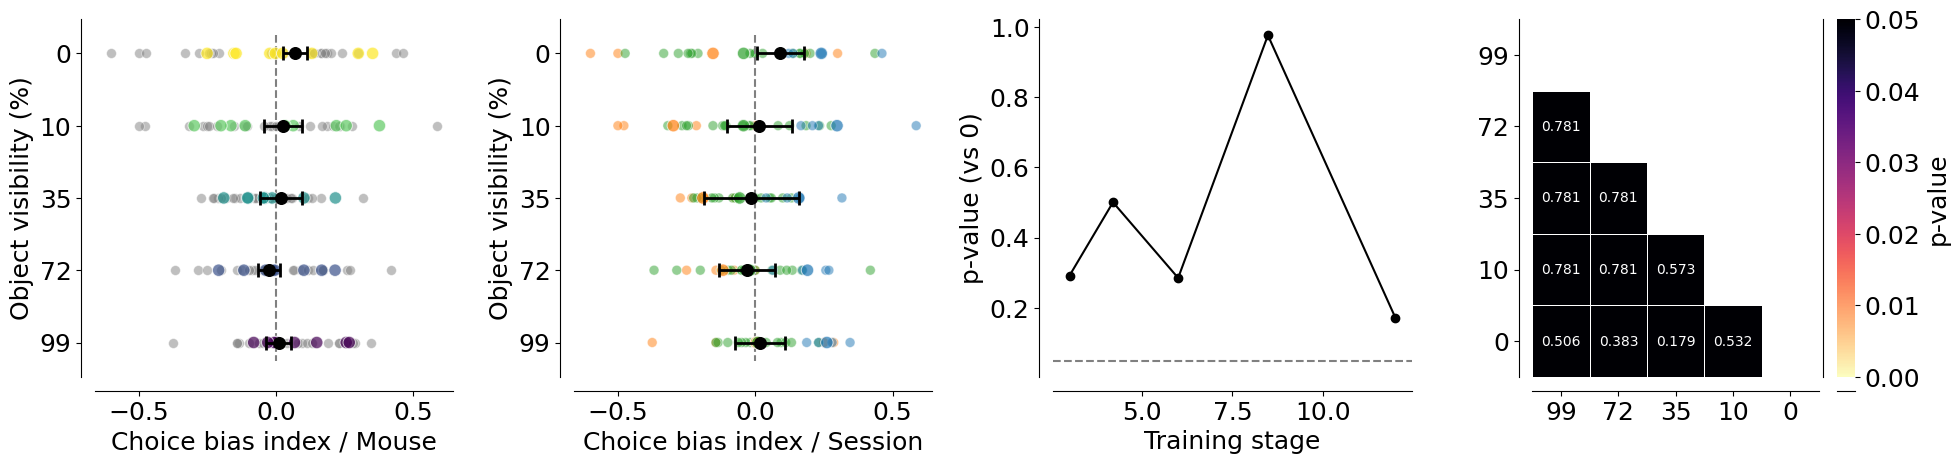

In [ ]:
trial_df["trial_bias"] = 2 * trial_df["trial_left_choice"] - 1 

# Choice bias per mouse and per lab
fig, ax = plt.subplots(1, 4, figsize=(20, 5))
plotting.plot_rate(
    df=trial_df,
    label_x="trial_left_choice",
    plot_bias=True,
    per_aperture=True,
    ax=ax[0],
    cmap=plotting.colors_multi_aperture,
    per_mouse=True,
)
ax[0].vlines(
    0,
    ymin=-0.25,
    ymax=len(trial_df.aperture.unique()) - 0.75,
    linestyles="dashed",
    colors="grey",
)

ax[0].set_ylabel("Object visibility (%)")
ax[0].set_xlabel("Choice bias index / Mouse")
ax[0].set_yticks([0, 1, 2, 3, 4], ["0", "10", "35", "72", "99"])

ax[0].legend([], [], frameon=False)
sns.despine(offset=10)

plotting.plot_rate(
    df=trial_df,
    label_x="trial_left_choice",
    per_aperture=True,
    plot_bias=True,
    ax=ax[1],
    cmap=plotting.colors_multi_aperture,
    per_lab=True,
)
ax[1].vlines(
    0,
    ymin=-0.25,
    ymax=len(trial_df.aperture.unique()) - 0.75,
    linestyles="dashed",
    colors="grey",
)

ax[1].set_ylabel("Object visibility (%)")
ax[1].set_xlabel("Choice bias index / Session")
ax[1].set_yticks([0, 1, 2, 3, 4], ["0", "10", "35", "72", "99"])

ax[1].legend([], [], frameon=False)

# One-sample t-test of bias against 0 (null) per training stage
apertures_ = []
for stage in sorted(trial_df.aperture.unique()):
    vals = trial_df.loc[trial_df.aperture == stage, "trial_bias"]
    t_stat, p_val = stats.ttest_1samp(vals, 0)
    apertures_.append({
        "aperture": stage,
        "n": len(vals),
        "mean_bias": vals.mean(),
        "t_stat": t_stat,
        "df": max(len(vals) - 1, 0),
        "p_value": p_val,
    })
apertures_df = pd.DataFrame(apertures_)
print("One-sample t-tests vs 0 (bias)")
print(apertures_df)

# Plot p-values only (no bar/box)
ax[2].plot(apertures_df["aperture"], apertures_df["p_value"], 
           marker="o", linestyle="-", color="k")
ax[2].axhline(0.05, color="grey", linestyle="--")
ax[2].set_xlabel("Training stage")
ax[2].set_ylabel("p-value (vs 0)")

# Plot p-values of the multi-comparison test
p_values = get_multi_performance_p_val(trial_df, y_var="trial_bias")
plot_aperture_heatmap(p_values, ax=ax[3])
ax[3].set_xticks([4.5, 3.5, 2.5, 1.5, 0.5], ["0", "10", "35", "72", "99"])
ax[3].set_yticks([4.5, 3.5, 2.5, 1.5, 0.5], ["0", "10", "35", "72", "99"])

mean_mouse = trial_df.groupby(["dataset", "aperture"], as_index=False).mean(numeric_only=True)
print(AnovaRM(mean_mouse, depvar="trial_bias", subject="dataset", within=["aperture"]).fit())

sns.despine(offset=10)
plt.tight_layout(pad=2)

plt.savefig(save_fig_path + "figure5_choice_bias.svg", transparent=True)

                Anova
         F Value Num DF  Den DF Pr > F
--------------------------------------
aperture 11.8531 4.0000 96.0000 0.0000



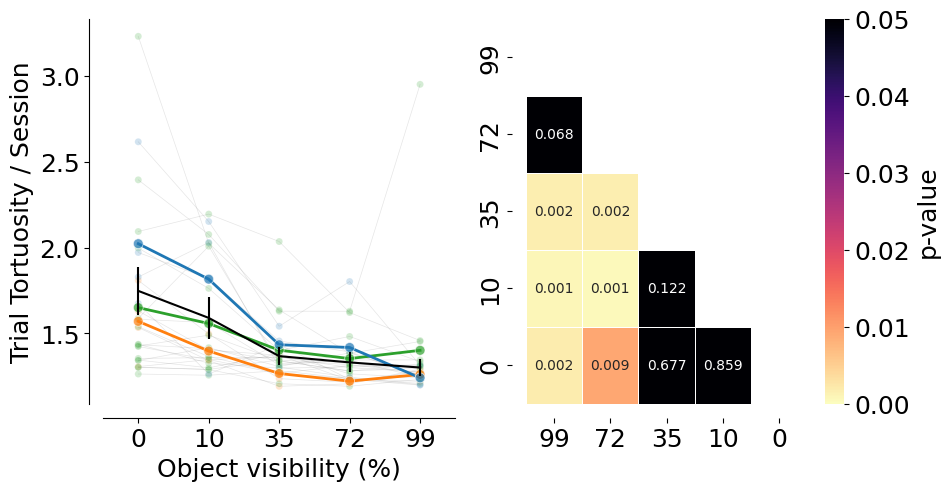

In [ ]:
fig, ax = plt.subplots(1, 2, figsize=(10, 5))

counts = (
    trial_df
    .groupby(["lab_id", "dataset", "aperture"], as_index=False)
    .trial_tortuosity.mean()
)

counts["count"] = counts["trial_tortuosity"]
counts = pd.DataFrame(counts.reset_index())
counts.aperture = counts.aperture.round(2).astype(str)

plotting._plot_bar_counts(
    counts=counts,
    label_x="aperture",
    alpha=0.2,
    ax=ax[0],
    per_lab=True,
    cmap=plotting.colors_aperture[0:2],
)
ax[0].invert_xaxis()

ax[0].set_xlim(-0.5, 4.5)
ax[0].set_xlabel("Object visibility (%)")
ax[0].set_ylabel("Trial Tortuosity / Session")
ax[0].set_xticks([0, 1, 2, 3, 4], ["0", "10", "35", "72", "99"])

ax[0].legend([], [], frameon=False)
sns.despine(offset=10)

p_values = get_multi_performance_p_val(trial_df,  y_var="trial_tortuosity")
plot_aperture_heatmap(p_values, ax=ax[1])
ax[1].set_xticks([4.5, 3.5, 2.5, 1.5, 0.5], ["0", "10", "35", "72", "99"])
ax[1].set_yticks([4.5, 3.5, 2.5, 1.5, 0.5], ["0", "10", "35", "72", "99"])

mean_mouse = trial_df.groupby(["dataset", "aperture"], as_index=False).mean(numeric_only=True)
print(AnovaRM(mean_mouse, depvar="trial_tortuosity", subject="dataset", within=["aperture"]).fit())

plt.savefig(save_fig_path + "figure5_tortuosity.svg", transparent=True)

# Trajectory analysis

In [16]:
dataset_list = []
for d in mouse_list:
    print(d)
    try:
        if len(MeanXYTrajectory() & f'dataset = "{d}"') > 0:
            dataset_list.append(pd.DataFrame((MeanXYTrajectory() & f'dataset = "{d}"').fetch(as_dict=True)[0]))
        else:
            print("dataset missing")
    except Exception as err:
        print(err, " dataset missing")
interpolated_df = pd.concat(dataset_list)
interpolated_df ["mouse_name"] = interpolated_df.dataset.str.split("_").str [0]

31726_2025-03-27_1
31726_2025-03-28_1
31728_2025-03-11_1
31728_2025-03-14_1
J729_2024-12-11_1
J729_2024-12-12_1
J729_2024-12-13_1
J729_2024-12-15_1
Jacana_2024-08-21_1
Jacana_2024-08-22_1
Kiwi_2024-08-19_1
Kiwi_2024-08-20_1
Kiwi_2024-08-21_1
Lemming_2024-08-14_1
Lemming_2024-08-15_1
Lemming_2024-08-19_1
Nightingale_2024-08-15_1
Nightingale_2024-08-16_1
Nightingale_2024-08-21_1
Nightingale_2024-08-22_1
Oribi_2024-08-26_1
Oribi_2024-08-27_1
Oribi_2024-08-29_1
Pheasant_2024-08-26_1
Pheasant_2024-08-28_1


In [17]:
mean_xy = mean_xy_trajectory(interpolated_df, index_columns=["aperture", "trial_left_choice", "trial_length"])

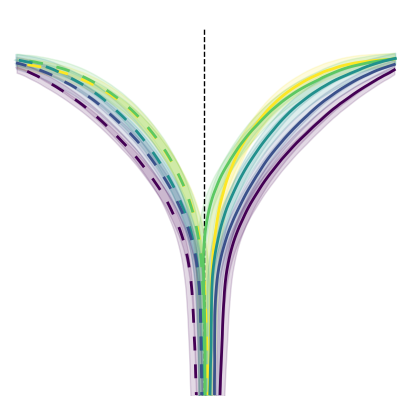

In [ ]:
plotting.plot_mean_xy_trajectory(mean_xy, cmap=plt.cm.viridis_r, color_by="aperture", style_by="choice")
plt.savefig(save_fig_path + "figure5_trajectories_time.svg", transparent=True)
plt.savefig(save_fig_path + "figure5_trajectories_time.png", transparent=True, dpi=300)

In [19]:
mean_mouse_xy = mean_xy_trajectory(interpolated_df, index_columns=["aperture", "mouse_name" ,"trial_left_choice", "trial_length"])

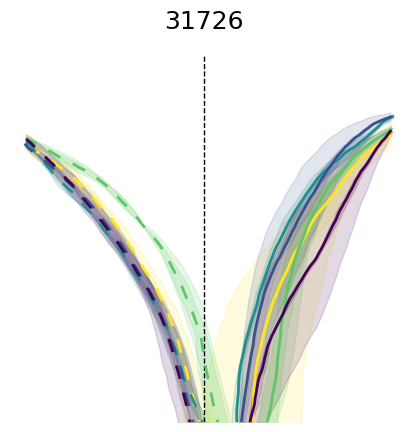

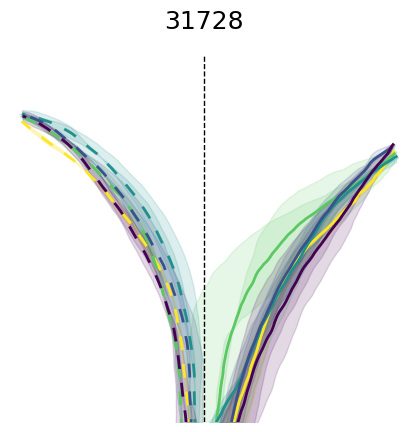

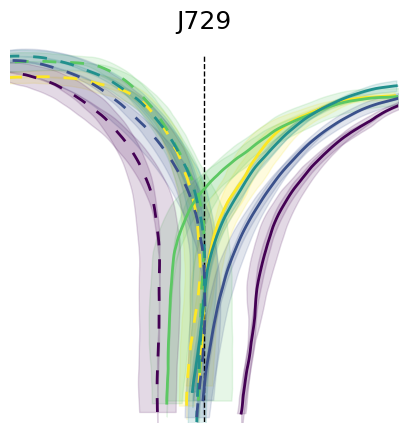

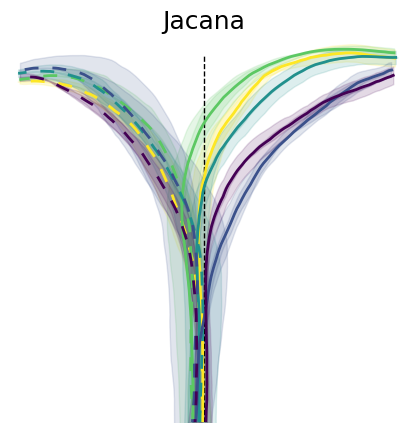

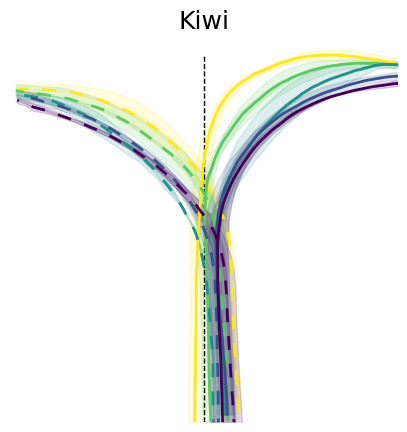

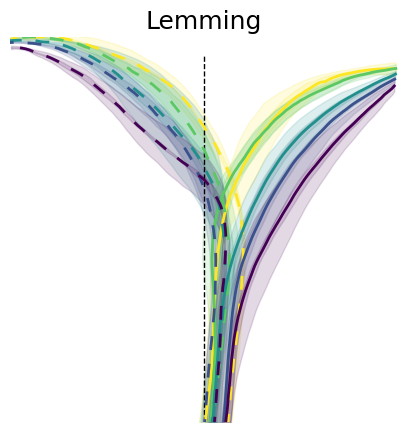

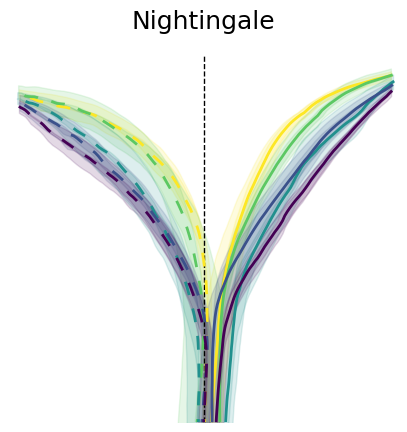

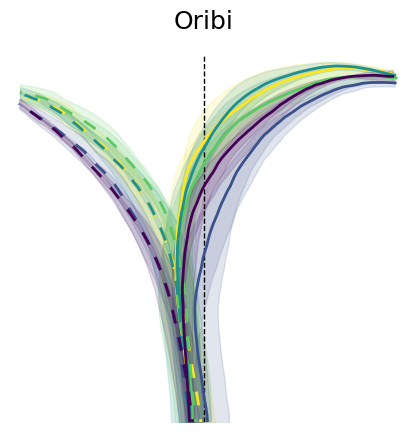

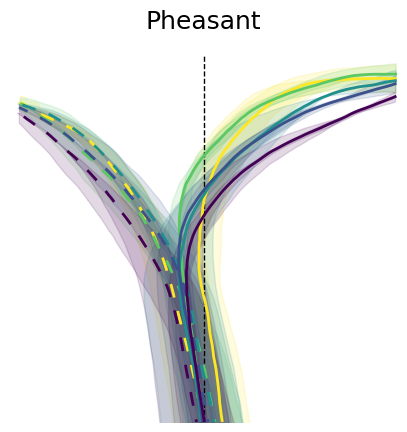

In [20]:
for m in mean_mouse_xy.mouse_name.unique():
    plotting.plot_mean_xy_trajectory(mean_mouse_xy[mean_mouse_xy.mouse_name == m], cmap=plt.cm.viridis_r, color_by="aperture", style_by="choice")
    plt.title(m)
    plt.savefig(save_fig_path + f"figure5_trajectories_time_{m}.svg", transparent=True)
    plt.savefig(save_fig_path + f"figure5_trajectories_time_{m}.png", transparent=True, dpi=300)

# Stats on trajectories

In [21]:
# takes 2 min to fetch
inter_df = []
for m in mouse_list:
    try:
        #print(m)
        inter_df.append(pd.DataFrame((InterpolatedTrials() & f'dataset="{m}"').fetch("dataset", "aperture", "trial", "trial_left_choice", "x", "y", "flip_one_side", "trial_rewarded", "velocity", "trial_length", as_dict=True)[0]))
    except Exception as err:
        print(err)
inter_df = pd.concat(inter_df)

aperture_to_occlusion = {
    12.0: 0,
    8.48: 10,
    6.0: 35,
    4.2: 72,
    3.0: 99
}

# Map the values
inter_df ['aperture'] = inter_df['aperture'].map(aperture_to_occlusion)


inter_df ["mouse_name"] = inter_df.dataset.str.split("_").str [0]
inter_df ["x_flipped"] = inter_df.x * inter_df.flip_one_side
data = utils.create_bins(inter_df [inter_df.trial_rewarded == 1.0].copy())

mean_mouse = (
    data.groupby(
        ["dataset", "trial_left_choice", "aperture", "bin_centers", "trial"],
        as_index=False,
    )
    .mean(numeric_only=True)
    .copy()
)

mean_mouse = (
    mean_mouse.groupby(["dataset", "aperture", "bin_centers"], as_index=False)
    .mean(numeric_only=True)
    .copy()
)

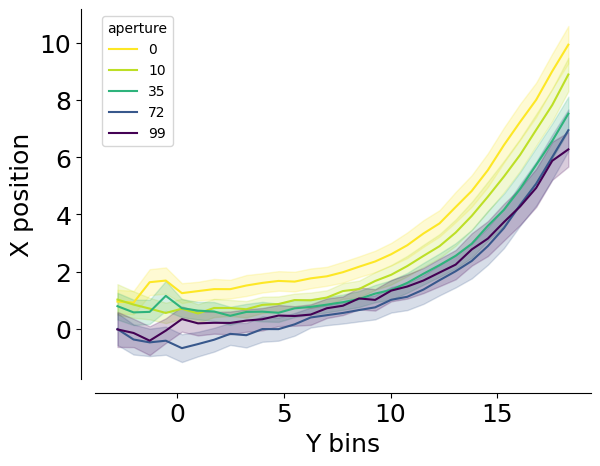

In [22]:
stats_df = mean_mouse[(mean_mouse.bin_centers > -3) & (mean_mouse.bin_centers < 19)]
sns.lineplot(data = stats_df, x="bin_centers", y="x_flipped", hue="aperture", palette= "viridis_r",errorbar="se")
plt.xlabel("Y bins")
plt.ylabel("X position")
sns.despine(offset=10)
plt.savefig(save_fig_path + "figure5_x_pos.svg")

In [23]:
print(
    AnovaRM(
        data=stats_df,
        depvar="x_flipped",
        subject="dataset",
        within=["aperture", "bin_centers"],
    ).fit()
)

                         Anova
                     F Value   Num DF    Den DF  Pr > F
-------------------------------------------------------
aperture               8.0835   4.0000   96.0000 0.0000
bin_centers          112.8314  28.0000  672.0000 0.0000
aperture:bin_centers   3.4522 112.0000 2688.0000 0.0000



In [24]:
p_value_df = get_p_values_multi(stats_df, x_var="bin_centers", y_var="x_flipped")

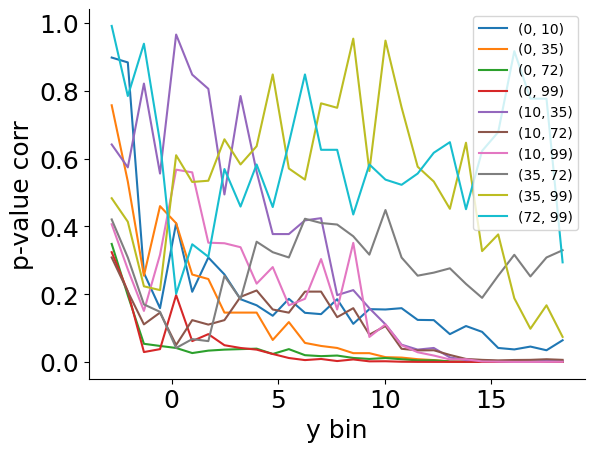

In [25]:
sns.lineplot(data = p_value_df, x="bin", y="p_value_corr", hue=zip(p_value_df.aperture1, p_value_df.aperture2))
plt.ylabel("p-value corr")
plt.xlabel("y bin")
plt.savefig(save_fig_path + "figure5_pos_pvalue.svg", transparent=True)

In [26]:
p_value_df.pivot(index = "bin", columns=["aperture1", "aperture2"], values=["p_value_corr"])

p_value_corr                                                        \
aperture1           0                                           10             
aperture2           10        35        72            99        35        72   
bin                                                                            
-2.8065       0.897931  0.757126  0.348106  3.237065e-01  0.641499  0.308160   
-2.0510       0.883606  0.532195  0.196231  2.078158e-01  0.573962  0.207402   
-1.2955       0.262327  0.254446  0.053485  2.908923e-02  0.821208  0.110796   
-0.5405       0.158554  0.459583  0.047118  3.772452e-02  0.555697  0.145532   
 0.2145       0.409242  0.409242  0.041169  1.970856e-01  0.965795  0.049873   
 0.9695       0.206988  0.257820  0.026134  6.141310e-02  0.847484  0.123293   
 1.7245       0.308160  0.244548  0.033311  8.197420e-02  0.805703  0.110132   
 2.4795       0.258115  0.145532  0.036280  4.927738e-02  0.494100  0.123293   
 3.2345       0.185044  0.145532  0.037725  4.116897e-02  0.784462  0.192026   
 3.9895       0.167072  0.145532  0.039146  3.628040e-02  0.560874  0.210801   
 4.7445       0.136188  0.064814  0.023438  2.343760e-02  0.377184  0.154692   
 5.5000       0.186174  0.117540  0.037725  1.154184e-02  0.377184  0.145297   
 6.2555       0.144871  0.056101  0.019865  5.406302e-03  0.417615  0.207402   
 7.0105       0.140953  0.047118  0.017031  8.698676e-03  0.424107  0.207402   
 7.7655       0.185044  0.041169  0.018816  2.574764e-03  0.197127  0.132068   
 8.5205       0.112372  0.025853  0.011730  7.372923e-03  0.211862  0.158554   
 9.2755       0.155703  0.025845  0.008796  1.702925e-03  0.158476  0.080552   
 10.0305      0.154692  0.014046  0.011542  1.969001e-03  0.110796  0.105877   
 10.7855      0.158554  0.012827  0.007921  5.542437e-04  0.050860  0.038791   
 11.5405      0.123978  0.008064  0.004603  1.384075e-04  0.036280  0.033963   
 12.2955      0.123293  0.005406  0.004635  7.110094e-05  0.041169  0.034421   
 13.0510      0.081974  0.001320  0.001593  5.453335e-05  0.013244  0.020594   
 13.8065      0.105877  0.000749  0.000697  4.022956e-05  0.005406  0.008796   
 14.5615      0.088696  0.000480  0.000480  7.027763e-06  0.005105  0.006035   
 15.3165      0.041169  0.000071  0.000139  1.590392e-06  0.002077  0.004525   
 16.0715      0.036856  0.000057  0.000220  3.844270e-07  0.001401  0.005699   
 16.8265      0.045286  0.000055  0.000103  2.996033e-07  0.001401  0.006063   
 17.5815      0.034421  0.000057  0.000064  2.158516e-07  0.002746  0.007921   
 18.3365      0.063936  0.000138  0.000095  1.406983e-06  0.002883  0.006087   

                                                   
aperture1                  35                  72  
aperture2        99        72        99        99  
bin                                                
-2.8065    0.406231  0.420379  0.482906  0.991247  
-2.0510    0.273180  0.308160  0.413580  0.784462  
-1.2955    0.150450  0.169621  0.223043  0.938739  
-0.5405    0.316378  0.147768  0.211862  0.648299  
 0.2145    0.567149  0.041169  0.609715  0.200744  
 0.9695    0.559237  0.067326  0.530911  0.347025  
 1.7245    0.351757  0.061363  0.534536  0.310151  
 2.4795    0.350096  0.253754  0.656833  0.569077  
 3.2345    0.338382  0.185044  0.582518  0.458359  
 3.9895    0.230936  0.354583  0.636369  0.582518  
 4.7445    0.279801  0.323707  0.848121  0.456924  
 5.5000    0.167072  0.308160  0.570685  0.645255  
 6.2555    0.186136  0.422375  0.537779  0.848121  
 7.0105    0.303485  0.409802  0.762906  0.625795  
 7.7655    0.154707  0.405293  0.749726  0.625795  
 8.5205    0.351238  0.370689  0.953778  0.434953  
 9.2755    0.073653  0.316472  0.563237  0.582518  
 10.0305   0.110796  0.448077  0.947968  0.537779  
 10.7855   0.049277  0.307917  0.751048  0.522490  
 11.5405   0.028539  0.254446  0.575874  0.555697  
 12.2955   0.018816  0.263391  0.532195  0.617013  
 13.0510   0.007393  0.276115  0.451684  0.648299  
 13.8065   0.0079

# Velocity analysis

In [27]:
velocity_df = []
for m in mouse_list:
    #print(m)
    velocity_df.append(pd.DataFrame((MeanVelocities() & f'dataset="{m}"').fetch(as_dict=True)[0]))
velocity_df = pd.concat(velocity_df)

mean_mouse = velocity_df.groupby(["dataset", "aperture", "trial_length"],as_index=False).mean()

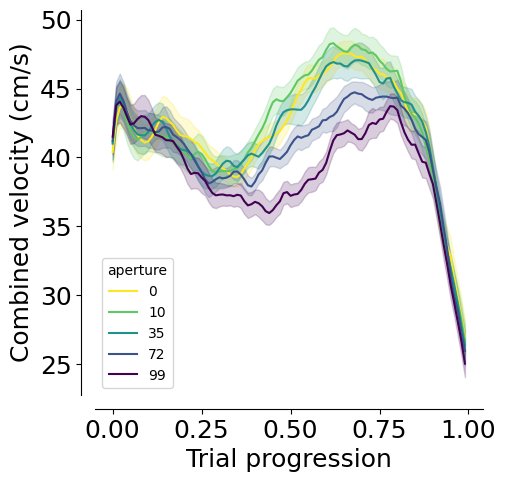

In [28]:
aperture_to_occlusion = {
    12.0: 0,
    8.48: 10,
    6.0: 35,
    4.2: 72,
    3.0: 99
}

# Map the values
mean_mouse['aperture'] = mean_mouse['aperture'].map(aperture_to_occlusion)

fig, ax = plt.subplots(1, 1, figsize=(5, 5))
sns.lineplot(
    data=mean_mouse,
    x="trial_length",
    y="velocity",
    palette=plotting.colors_multi_aperture,
    hue="aperture",
    errorbar="se",
    ax=ax,
)

sns.despine(offset=10)
ax.set_xlabel("Trial progression")
ax.set_ylabel("Combined velocity (cm/s)")
plt.savefig(save_fig_path + "figure5_velocity.svg", transparent=True)

In [29]:
print(
    AnovaRM(
        data=mean_mouse,
        depvar="velocity",
        subject="dataset",
        within=["aperture", "trial_length"],
    ).fit()
)

                         Anova
                      F Value  Num DF    Den DF  Pr > F
-------------------------------------------------------
aperture              14.1673   4.0000   96.0000 0.0000
trial_length          41.8922  99.0000 2376.0000 0.0000
aperture:trial_length  5.3963 396.0000 9504.0000 0.0000



In [30]:
p_value_df = get_p_values_multi(mean_mouse, x_var="trial_length", y_var="velocity")

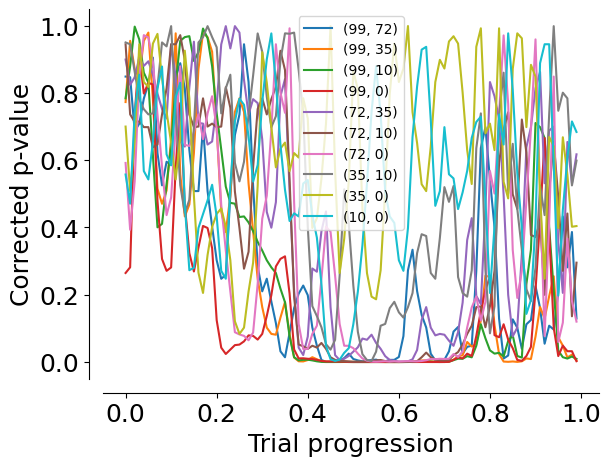

In [31]:
sns.lineplot(data = p_value_df, x="bin", y="p_value_corr", hue=zip(p_value_df.aperture1, p_value_df.aperture2))
plt.ylabel("Corrected p-value")
plt.xlabel("Trial progression")

sns.despine(offset=10)
plt.savefig(save_fig_path + "figure5_velocity_pvalue.svg", transparent=True)